In [29]:
from typing import List, Dict, Optional
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from model_ranking import (
    get_output_paths,
    load_h5,
)

/tmp/ipykernel_481892/4014105278.py:65: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))


Proportion non NaN patches = 0.81


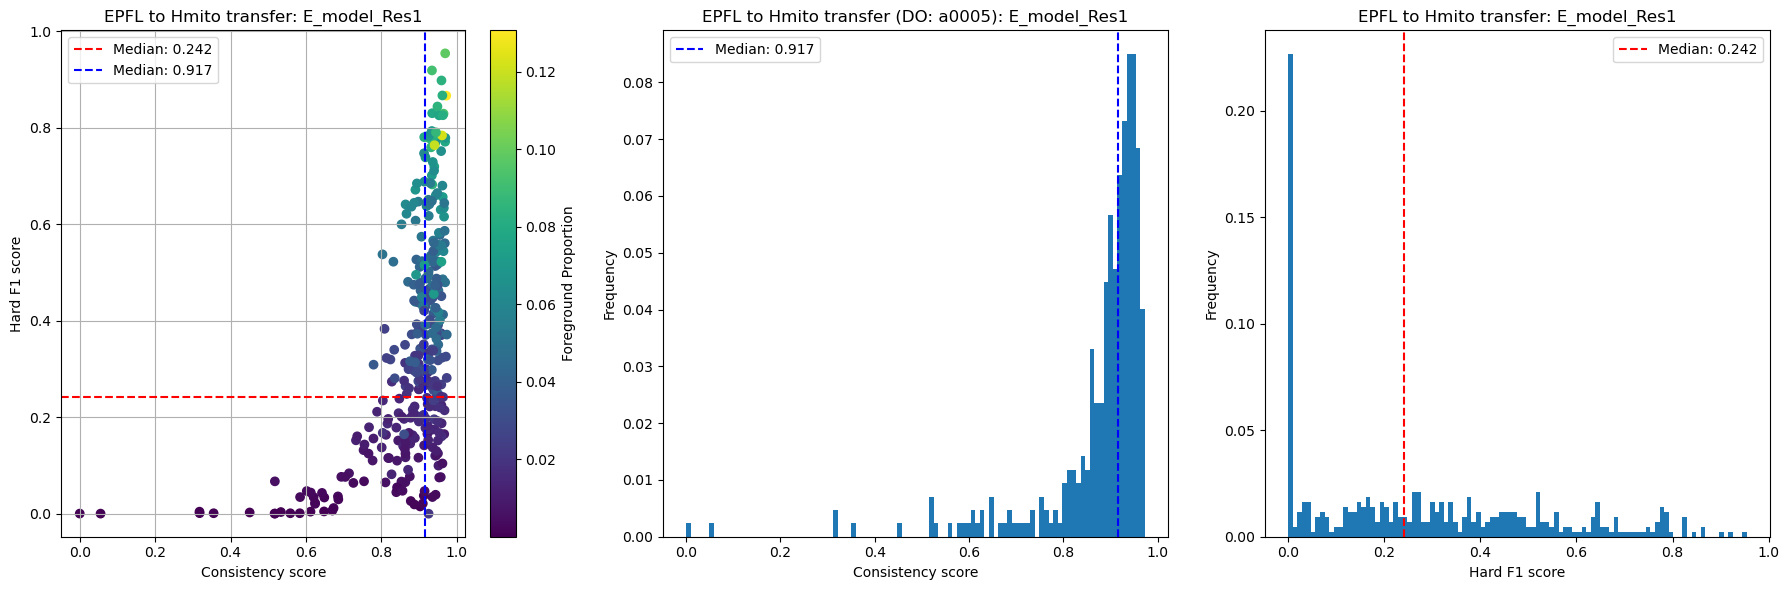

Proportion non NaN patches = 0.81


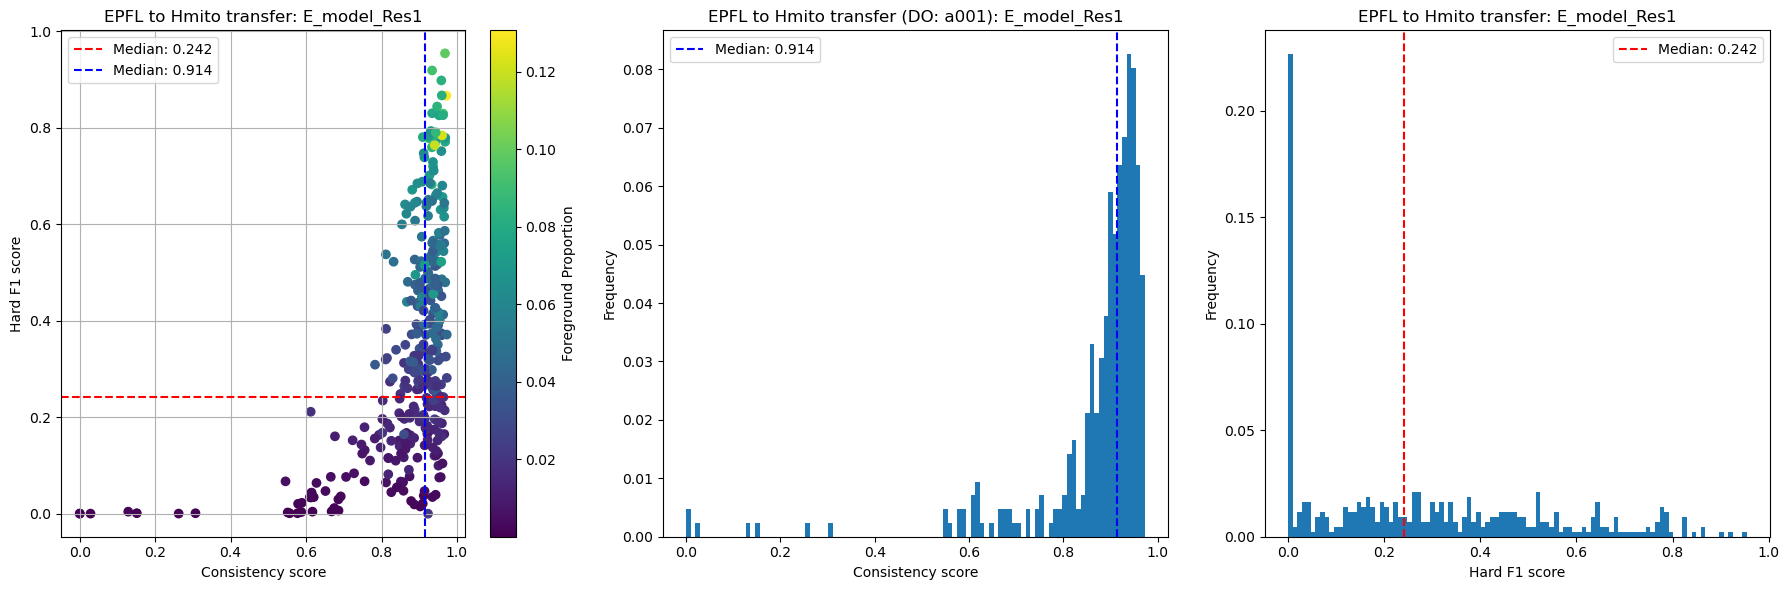

Proportion non NaN patches = 0.81


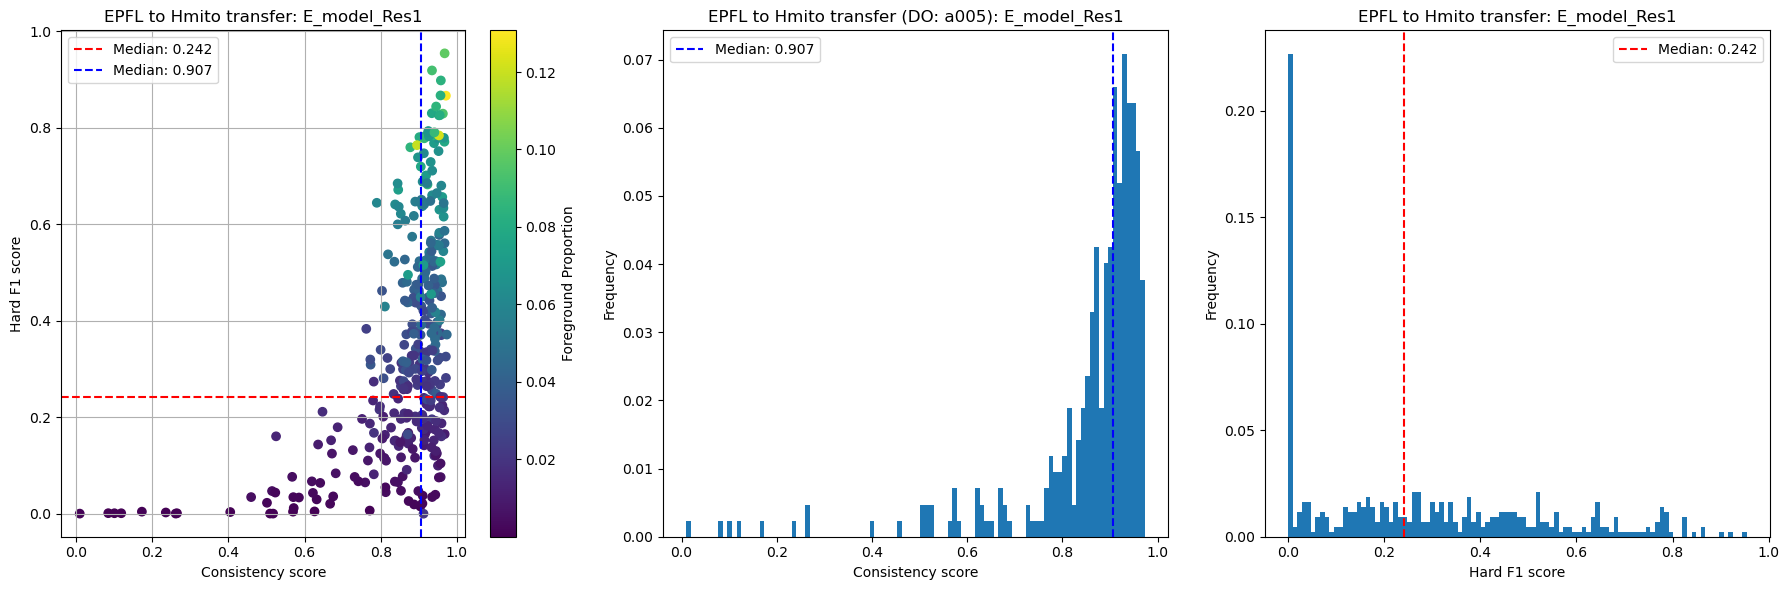

Proportion non NaN patches = 0.81


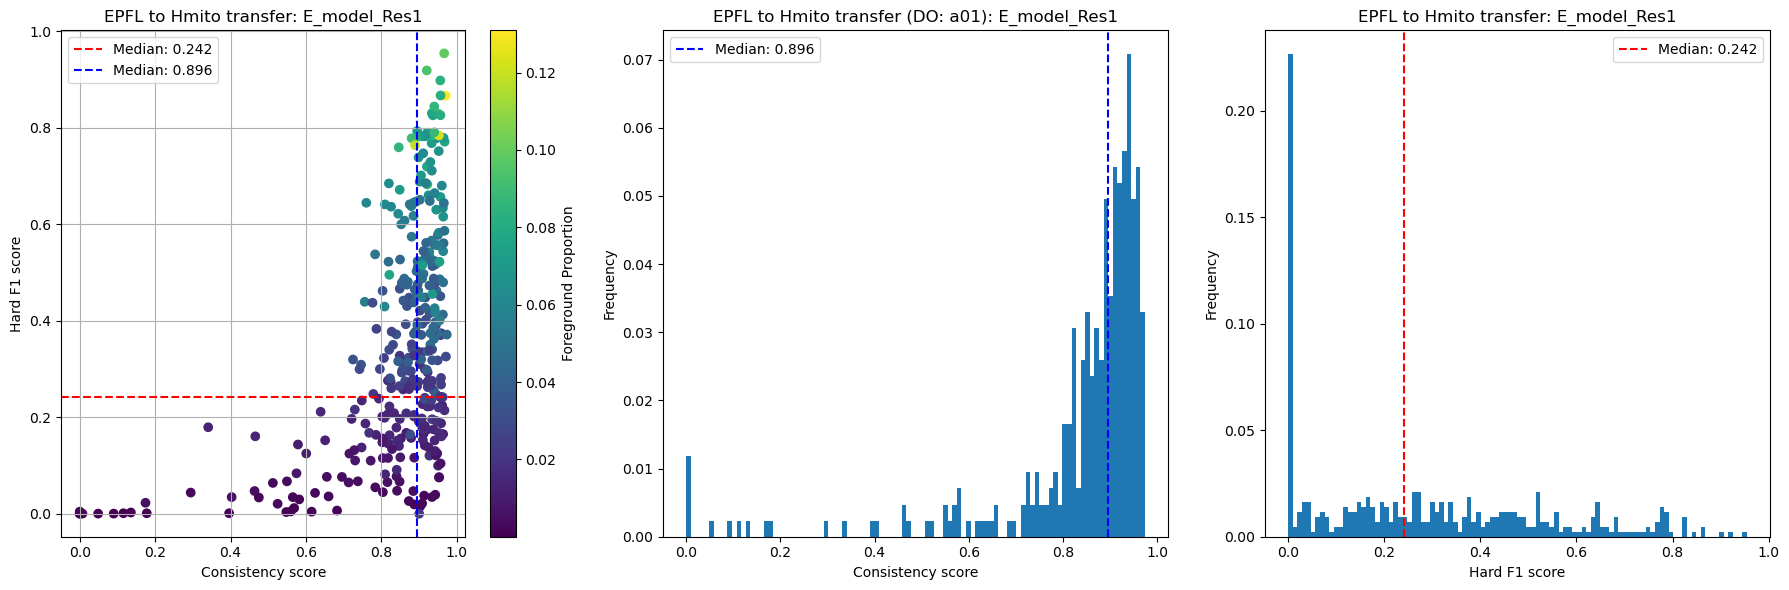

Proportion non NaN patches = 0.82


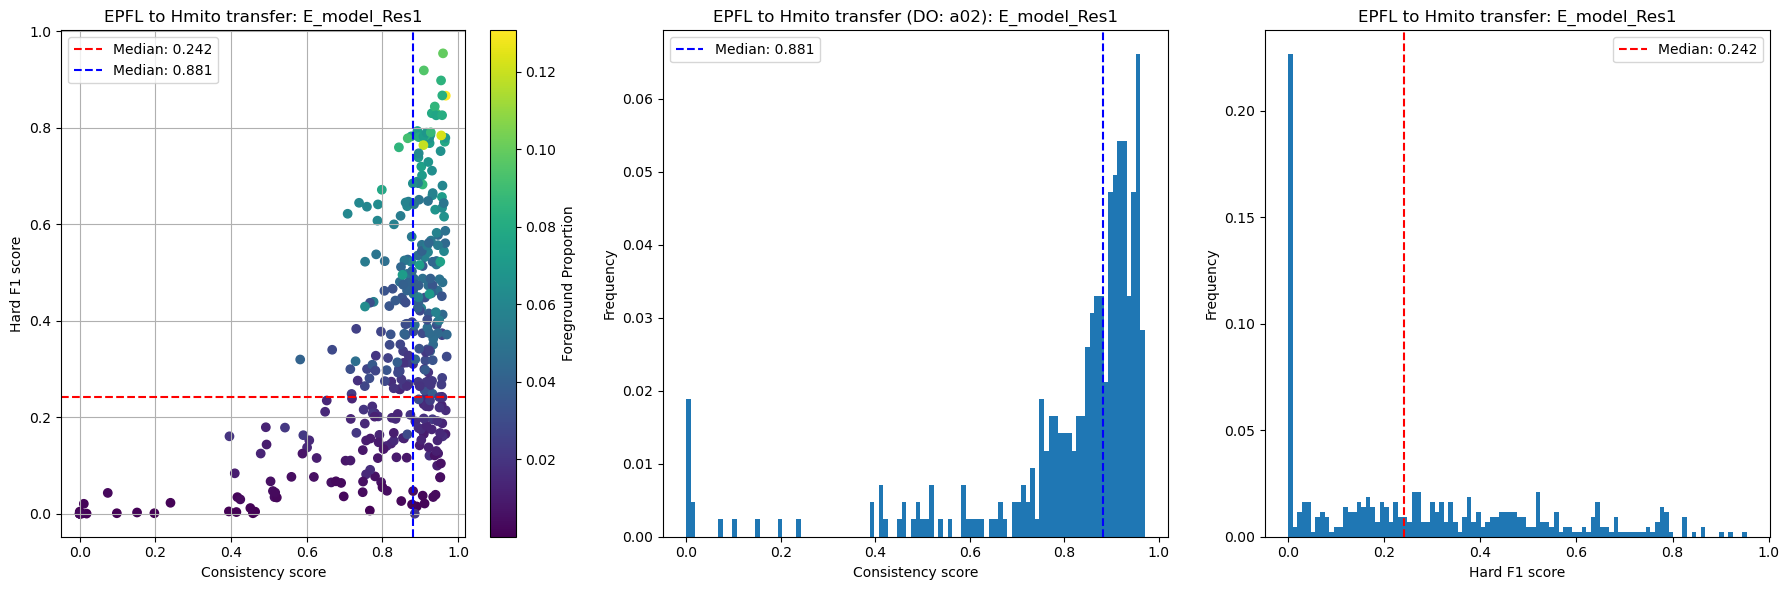

Proportion non NaN patches = 0.82


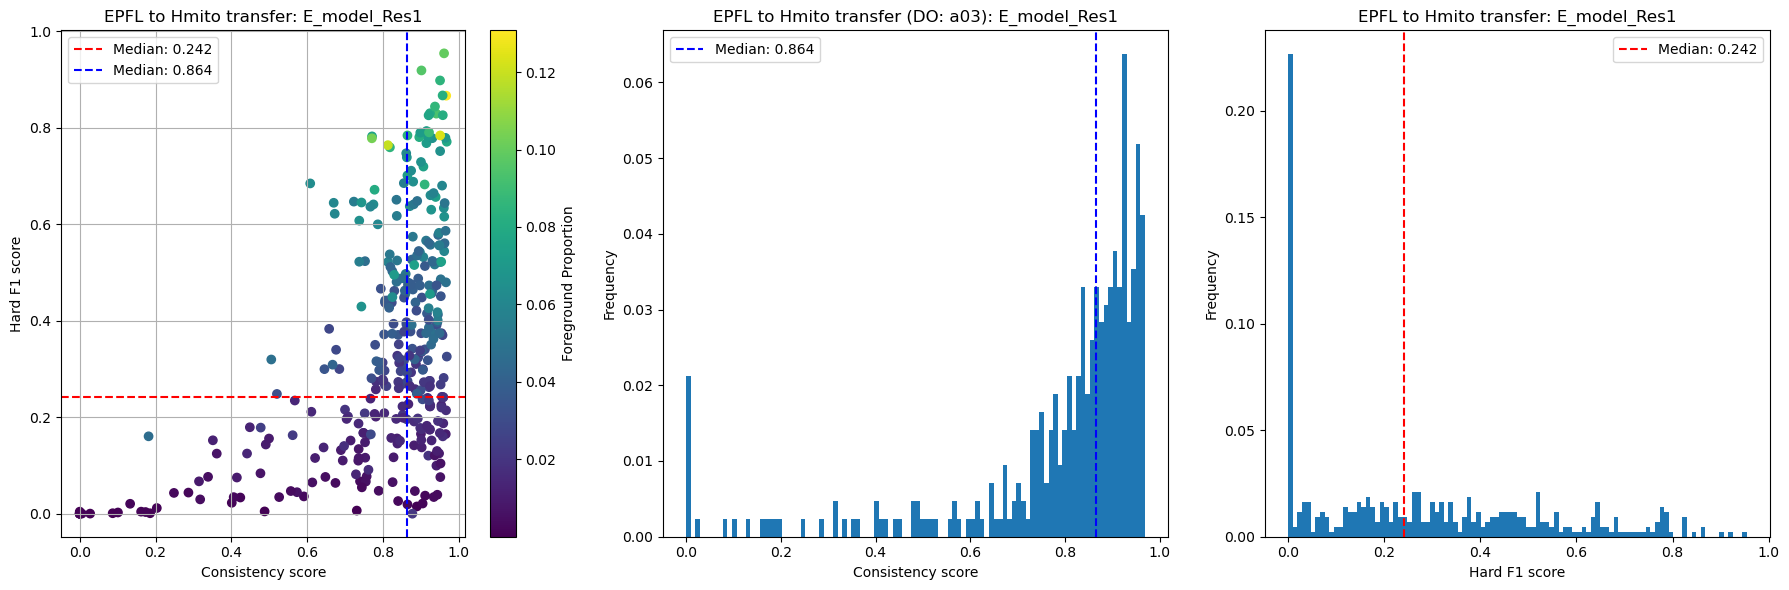

Proportion non NaN patches = 0.82


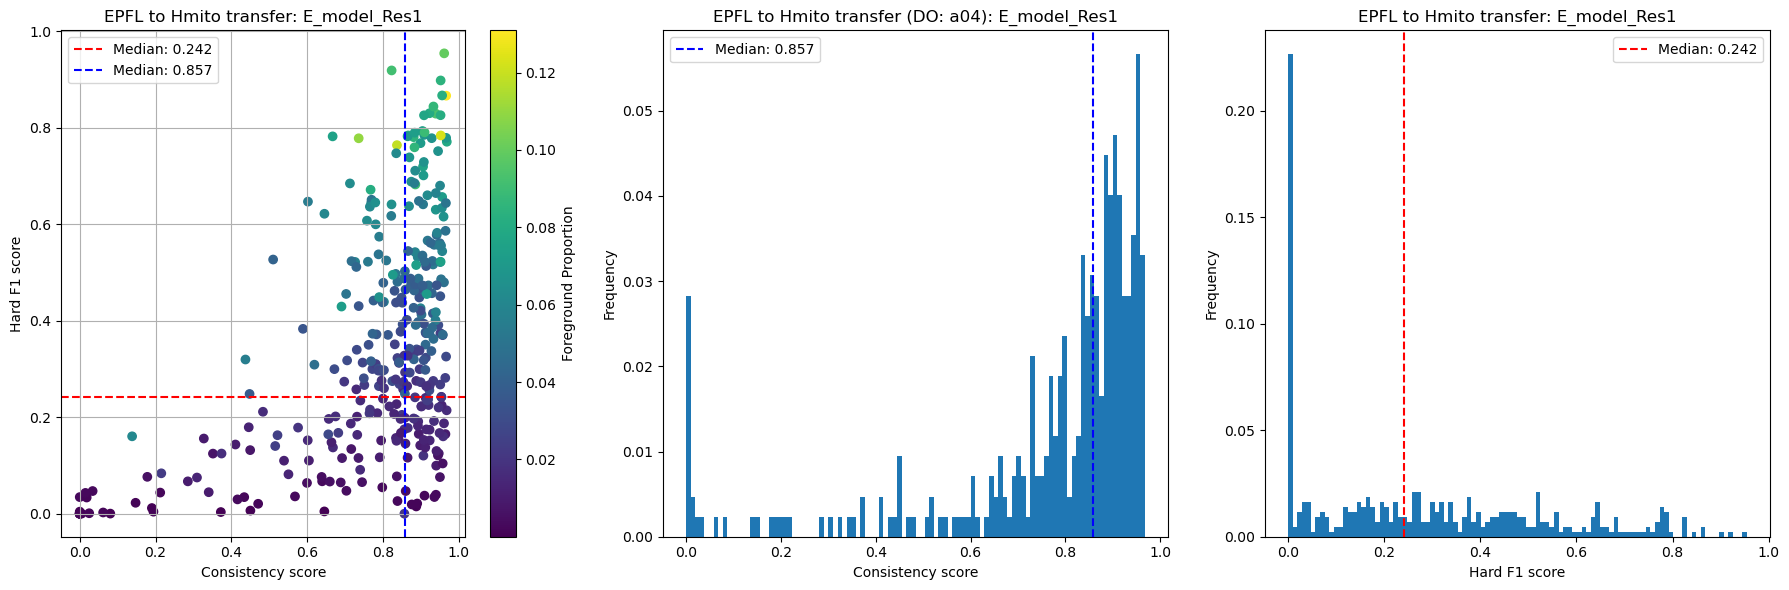

Proportion non NaN patches = 0.13


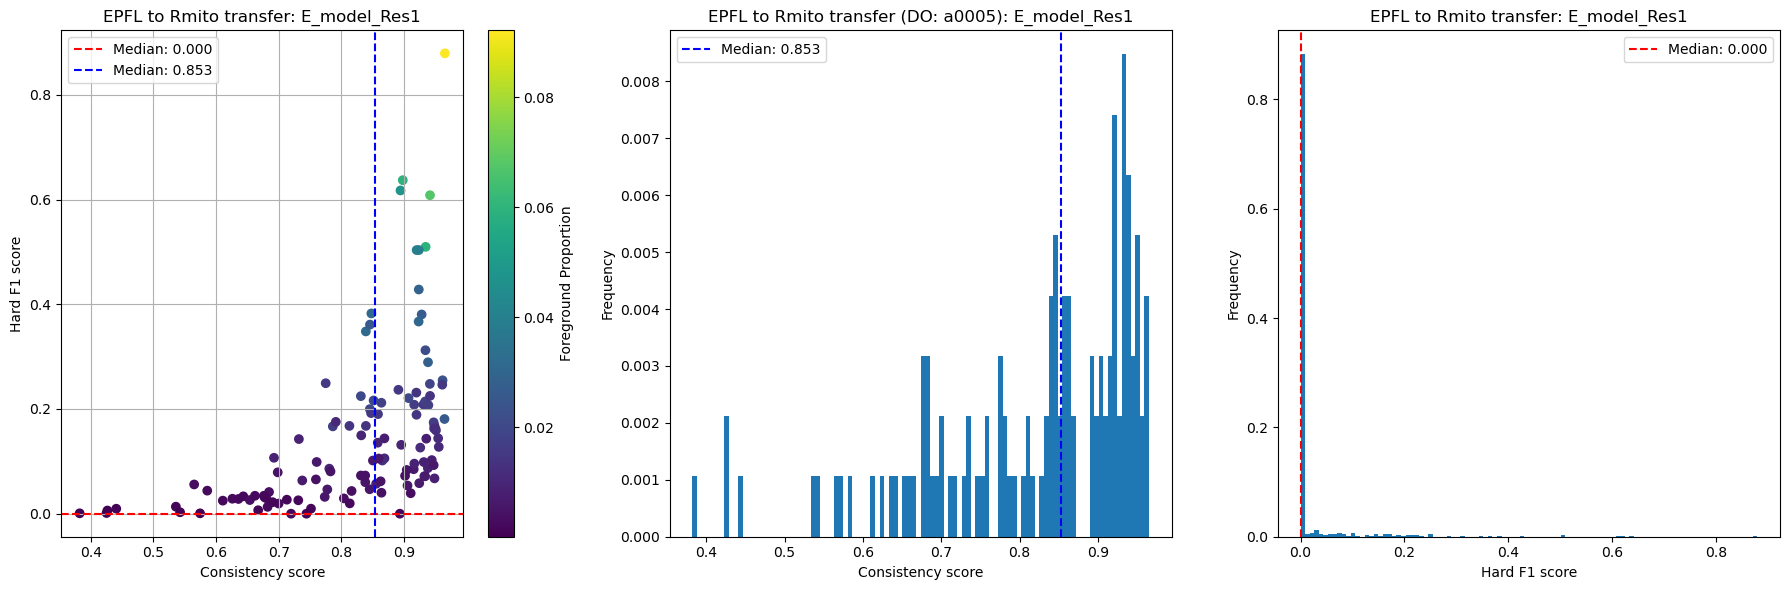

Proportion non NaN patches = 0.13


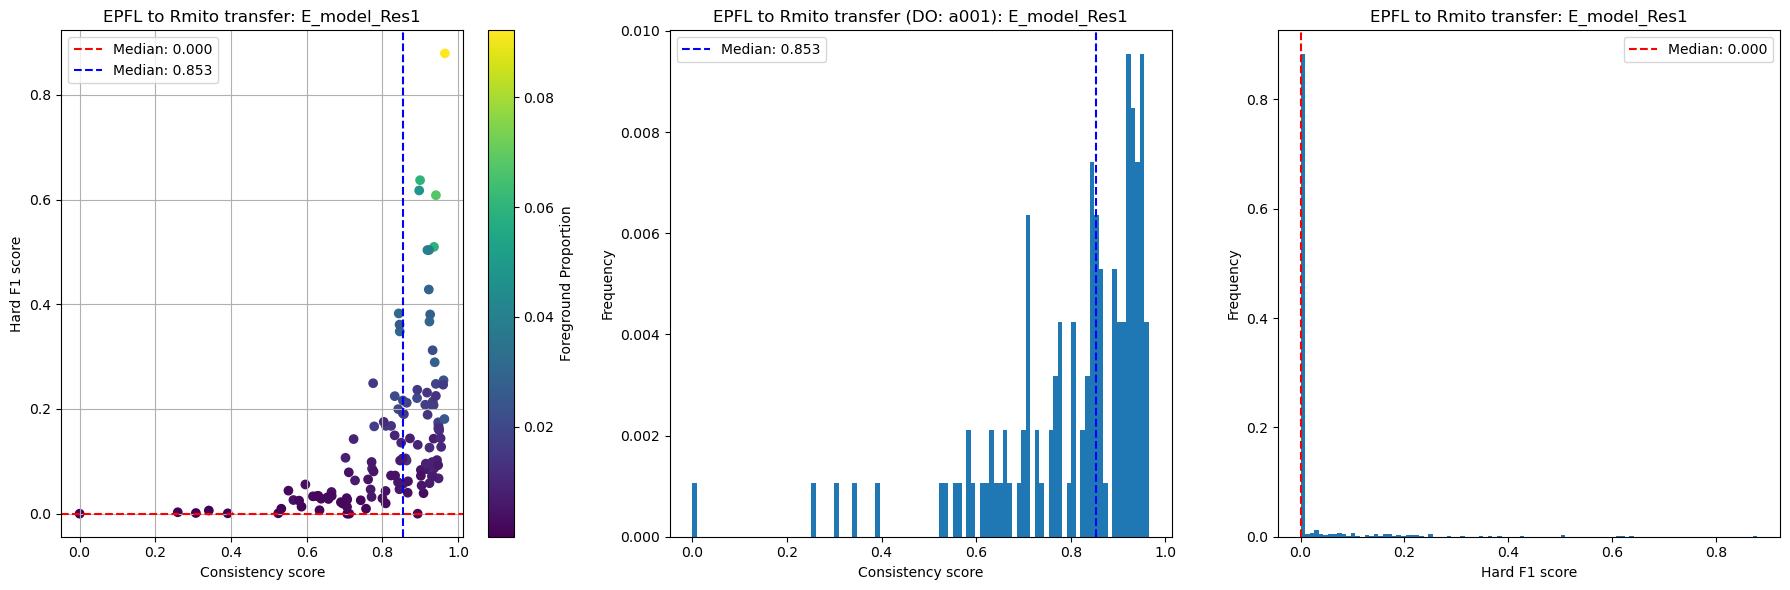

Proportion non NaN patches = 0.13


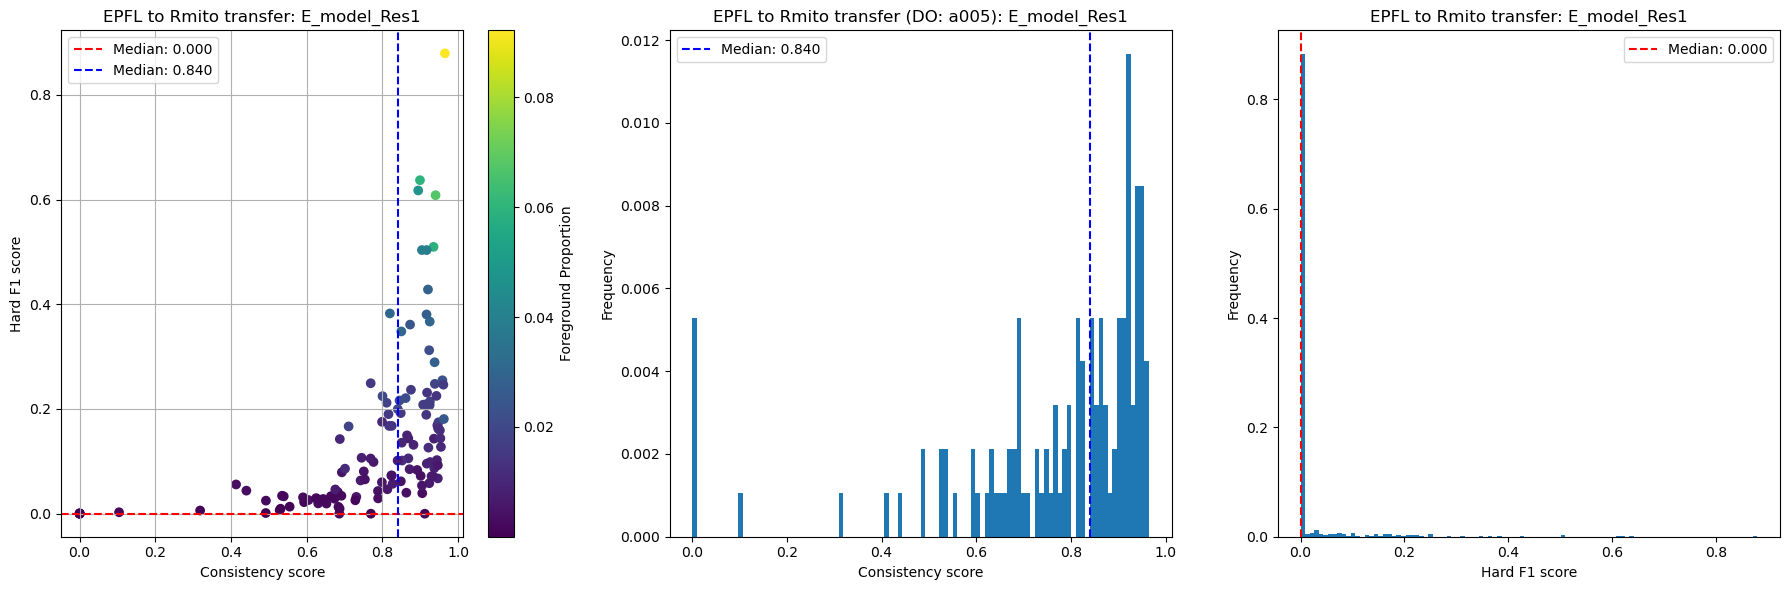

Proportion non NaN patches = 0.13


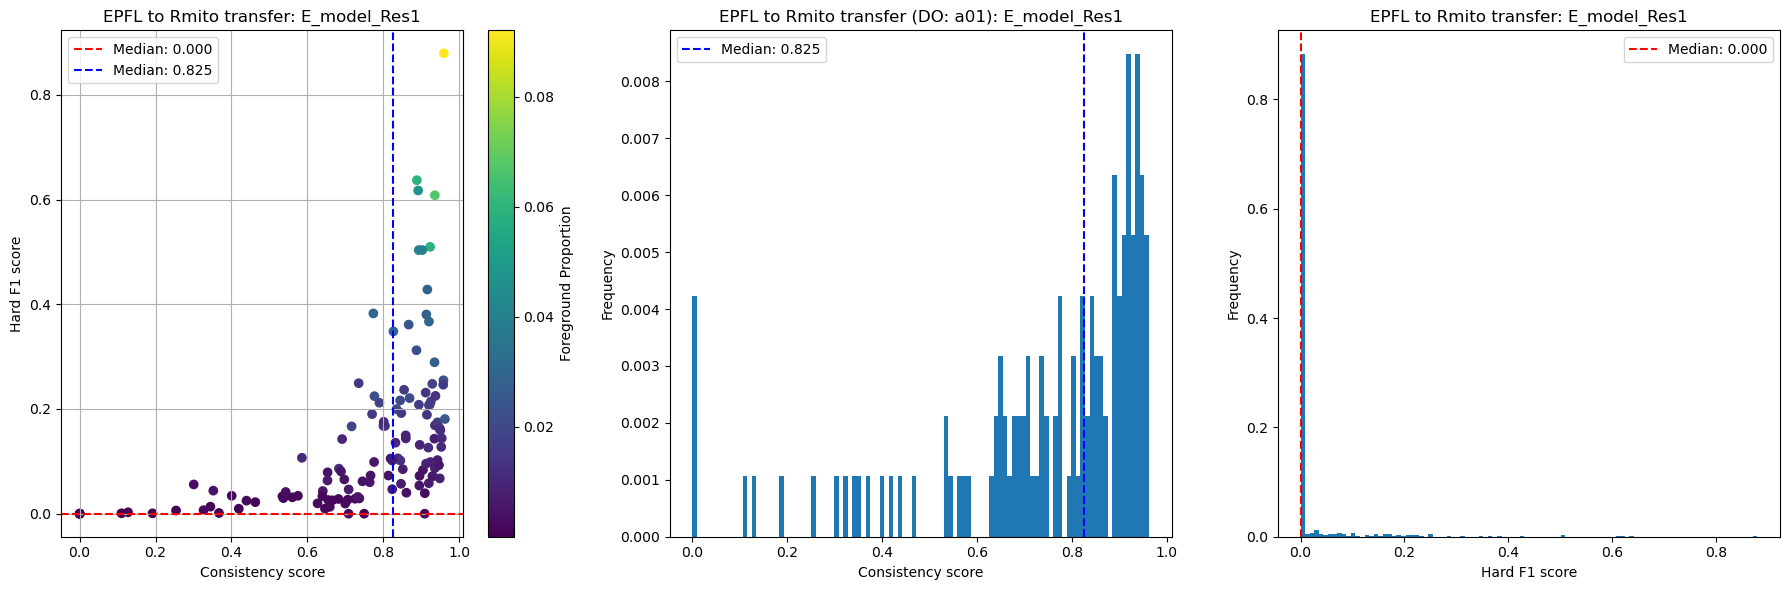

Proportion non NaN patches = 0.13


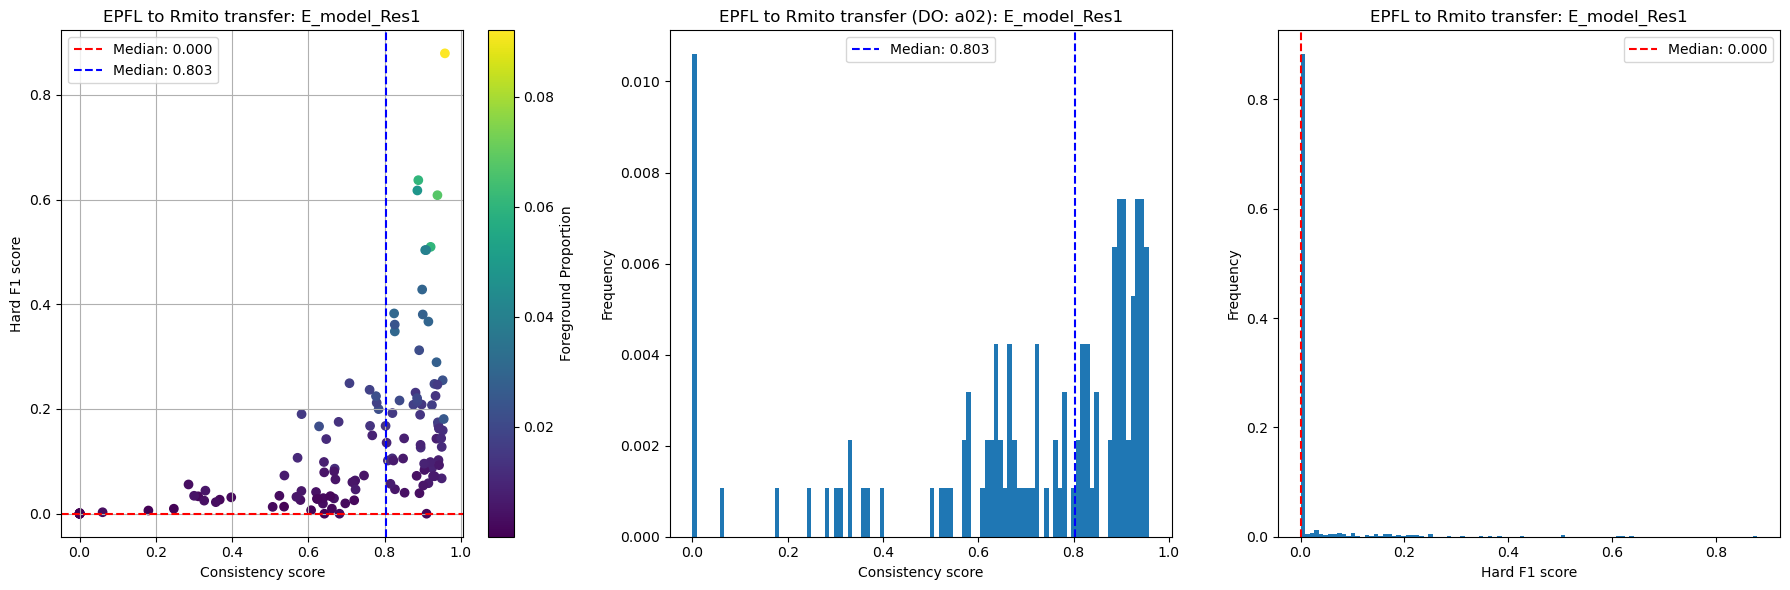

Proportion non NaN patches = 0.14


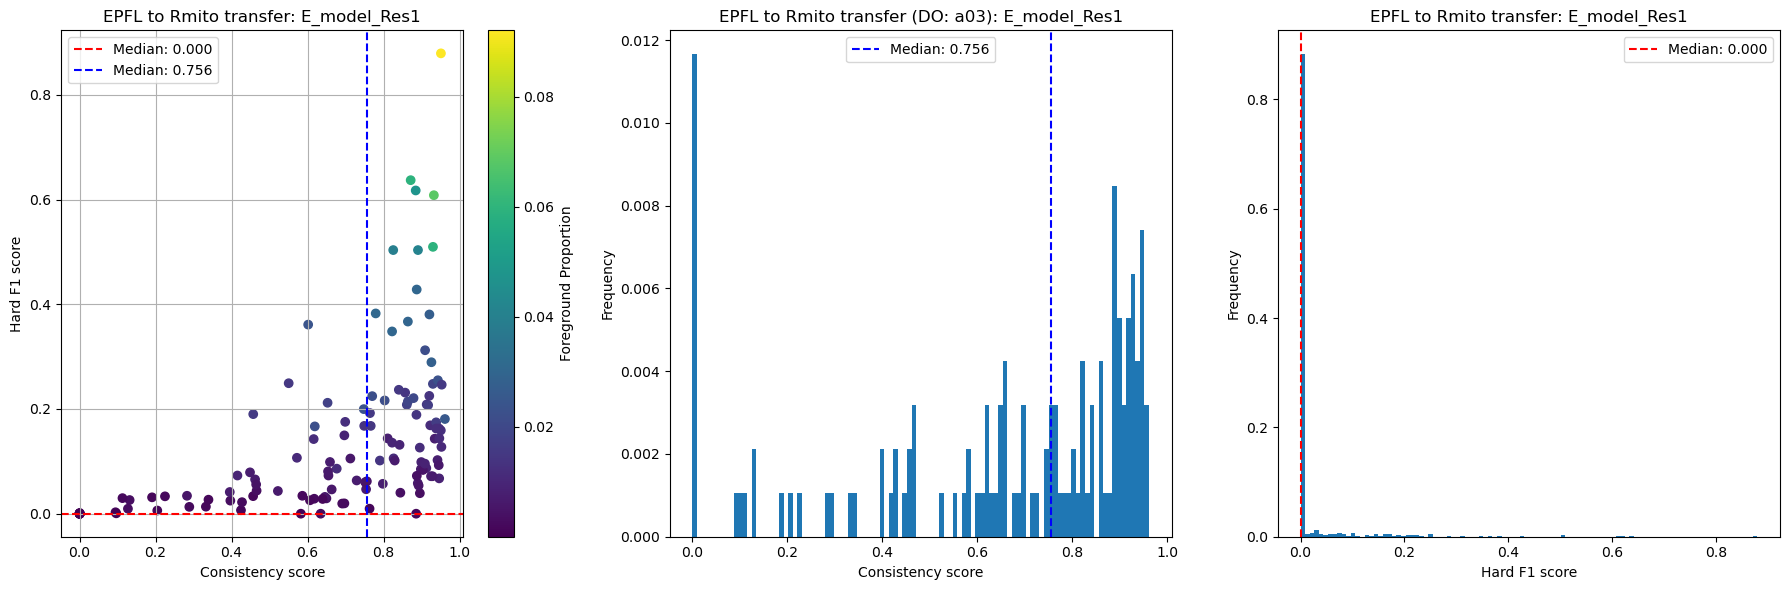

Proportion non NaN patches = 0.14


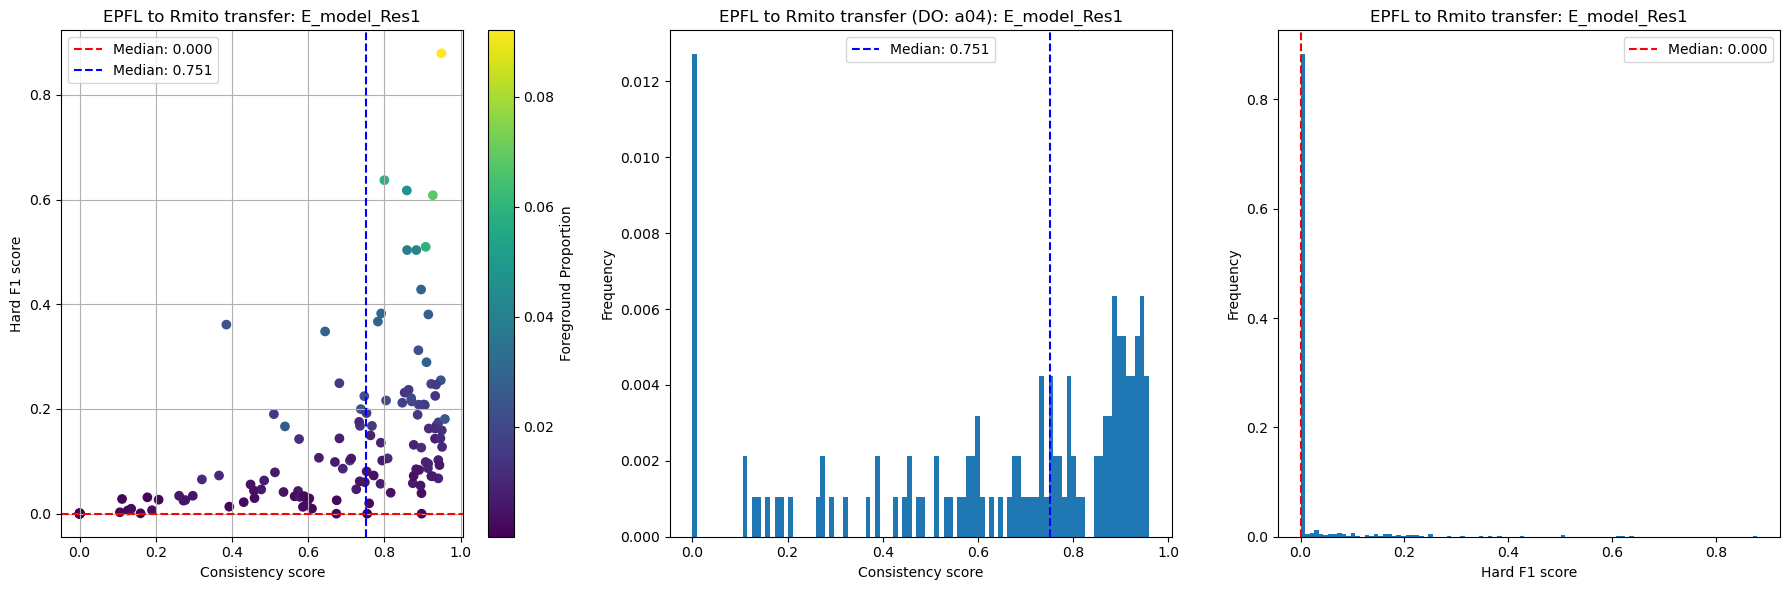

In [30]:
sources = {
    "EPFL": "E_model_Res1",
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["EPFL", "Hmito", "Rmito"]
targets=["Hmito", "Rmito"]
result_folders = {
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_key = "EI_consis"
selected_alphas = ["a0005", "a001", "a005", "a01", "a02", "a03", "a04"]
#targets = ["VNC"]
# foreground_thresholds: Optional[Dict[str, float]] = {
#     "EPFL": 0.04,
#     "Hmito": 0.04,
#     "Rmito": 0.04,
#     "VNC": 0.02,
# }
foreground_thresholds: Optional[Dict[str, float]] = None

for source, model_name in sources.items():
    for target in targets:
        none_paths = get_output_paths(
            source, 
            target, 
            {"none": []}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folders[target], 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(none_paths) == 1, f"Expected one path for {source} to {target} transfer: {model_name}, found {len(paths)}"
        direct_pred_path: List[Path] = list(Path(none_paths[0]).glob("*.h5"))
        for i in range(len(direct_pred_path)):
            if "metric_summary" in direct_pred_path[i].name:
                _ = direct_pred_path.pop(i)
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")[:,1]
        gt_foreground_patch_ids = load_h5(direct_pred_path[0], "foreground_patches_th01")
        eval_score_direct = eval_score_direct[gt_foreground_patch_ids]

        for perturbation_alpha in selected_alphas:

            DO_paths = get_output_paths(
                source, 
                target, 
                {"DO": [perturbation_alpha]}, 
                [None], 
                model_name, 
                "predictions", 
                result_folder = result_folders[target], 
                base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
            )
            
            DO_pred_path: List[Path] = list(Path(DO_paths[0]).glob("*.h5"))
            for i in range(len(DO_pred_path)):
                if "metric_summary" in DO_pred_path[i].name:
                    _ = DO_pred_path.pop(i)
        
            consis_score_direct = load_h5(DO_pred_path[0], consis_key)
            consis_score_direct = consis_score_direct[gt_foreground_patch_ids]
            consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))

            

            foreground_proportions = np.count_nonzero(~np.isnan(consis_score_direct), axis=(1,2))/consis_score_direct[0].size
            if foreground_thresholds is not None:
                sel_ids = np.where(foreground_proportions > foreground_thresholds[source])[0]
                consis_score_PP = consis_score_PP[sel_ids]
                eval_score_direct = eval_score_direct[sel_ids]
                foreground_proportions = foreground_proportions[sel_ids]
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)
            else:
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)

            print(f"Proportion non NaN patches = {(len(consis_score_PP) - np.isnan(consis_score_PP).sum()) / len(consis_score_PP):.2f}")
            _, axs = plt.subplots(1, 3, figsize=(18, 6))
            sc = axs[0].scatter(consis_score_PP, eval_score_direct, c=foreground_proportions, cmap='viridis')
            _ = axs[0].set_xlabel("Consistency score")
            _ = plt.colorbar(sc, ax=axs[0], label='Foreground Proportion')
            _ = axs[0].set_ylabel("Hard F1 score")
            _ = axs[0].grid()
            _ = axs[0].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[0].axhline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[0].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[0].legend()
            _ = axs[1].hist(consis_score_PP, bins=100, weights=np.ones_like(consis_score_PP) / len(consis_score_PP))
            _ = axs[1].set_title(f"{source} to {target} transfer (DO: {perturbation_alpha}): {model_name}")
            _ = axs[1].set_xlabel("Consistency score")
            _ = axs[1].set_ylabel("Frequency")
            _ = axs[1].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[1].legend()
            _ = axs[2].hist(eval_score_direct, bins=100, weights=np.ones_like(eval_score_direct) / len(eval_score_direct))
            _ = axs[2].axvline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[2].legend()
            _ = axs[2].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[2].set_xlabel("Hard F1 score")
            _ = axs[2].set_ylabel("Frequency")
            plt.tight_layout()
            plt.show()
        

In [28]:
np.sum(np.isnan(eval_score_direct)), np.sum(np.isnan(consis_score_PP))

(0, 3315)

# EtoR Predictions

In [31]:
R_path = "/scratch/talks/data/Rmito/test_converted.h5"
roi = [[0,150], [0,1280], [0, 1280]]
R_labels = load_h5(R_path, "labels", roi=roi)

In [32]:
EtoR_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Rmito_gap/feature_perturbation_consistency/FP_3/E_model_Res1/norm_Normalize/DO_a01/predictions/test_converted_predictions.h5"
EtoR_predictions = load_h5(EtoR_path, "predictions")
EtoR_consis = load_h5(EtoR_path, "EI_consis")
EtoR_f1 = load_h5(EtoR_path, "hard_f1")[:, 1]
EtoR_patch_indexes = load_h5(EtoR_path, "patch_index")
EtoR_gt_foreground_patch_ids = load_h5(EtoR_path, "foreground_patches_th01")

In [33]:
EtoR_predictions = EtoR_predictions[EtoR_gt_foreground_patch_ids]
EtoR_consis = EtoR_consis[EtoR_gt_foreground_patch_ids]
EtoR_f1 = EtoR_f1[EtoR_gt_foreground_patch_ids]
EtoR_patch_indexes = EtoR_patch_indexes[EtoR_gt_foreground_patch_ids]

In [34]:
EtoR_consis_PP = np.nanmean(EtoR_consis, axis=tuple(range(1, EtoR_consis.ndim)))
EtoR_foreground_proportions = np.count_nonzero(~np.isnan(EtoR_consis), axis=(1,2))/EtoR_consis[0].size

/tmp/ipykernel_481892/371863975.py:1: RuntimeWarning: Mean of empty slice
  EtoR_consis_PP = np.nanmean(EtoR_consis, axis=tuple(range(1, EtoR_consis.ndim)))


In [35]:
nan_ids = np.where(np.isnan(EtoR_consis_PP))[0]
print(f"Number of NaN consistency scores: {len(nan_ids)}")
print(f"Number of none NaN consistency scores: {len(EtoR_consis_PP) - len(nan_ids)}")

Number of NaN consistency scores: 820
Number of none NaN consistency scores: 124


In [38]:
consis_ids = np.where(EtoR_consis_PP >= 0.8)[0]
f1_ids = np.where(EtoR_f1 <= 0.2)[0]

overlap_ids = np.intersect1d(consis_ids, f1_ids)
print(f"Number of overlapping ids: {len(overlap_ids)}")

Number of overlapping ids: 43


In [37]:
consis_ids = np.where((EtoR_consis_PP >= 0.4) & (EtoR_consis_PP<=0.6))[0]
f1_ids = np.where(EtoR_f1 <= 0.2)[0]

overlap_ids = np.intersect1d(consis_ids, f1_ids)
print(f"Number of overlapping ids: {len(overlap_ids)}")

Number of overlapping ids: 10


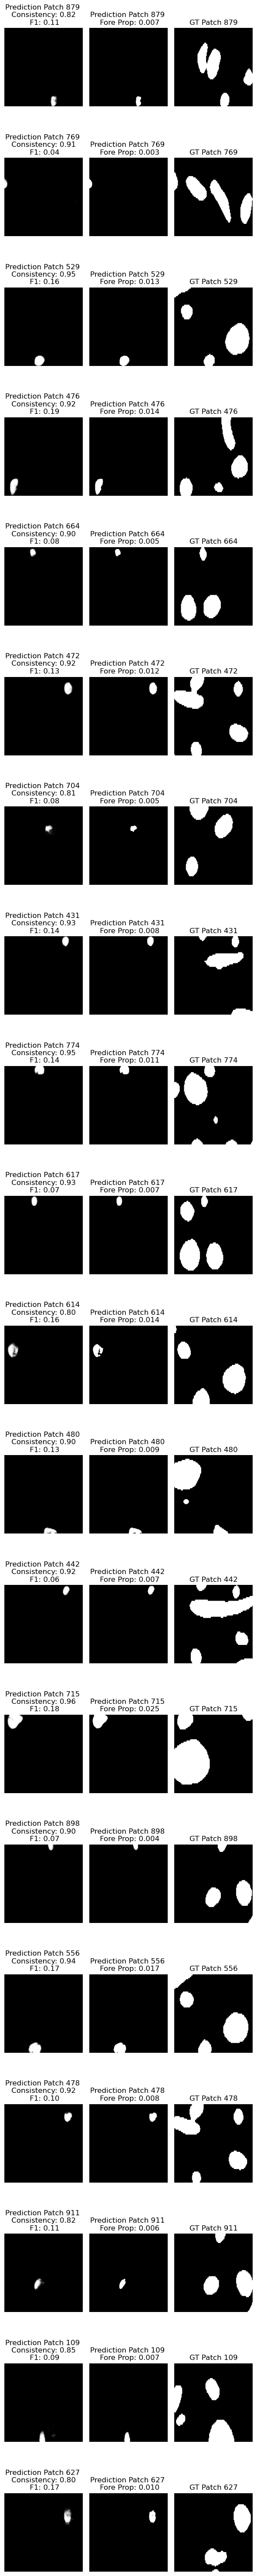

In [39]:
# Set random seed for reproducibility
np.random.seed(12)
num_samples =20

# Randomly select 10 patch indices from ids_zero
sample_indices = np.random.choice(overlap_ids, size=num_samples, replace=False)

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(6, 3 * len(sample_indices)))

for i, idx in enumerate(sample_indices):
    # Get patch coordinates
    z, y, x = EtoR_patch_indexes[idx]
    # Extract prediction and ground truth patch
    pred_patch = EtoR_predictions[idx, 0, 0]
    gt_patch = R_labels[z[0]:z[1], y[0]:y[1], x[0]:x[1]]

    # Plot prediction
    axes[i, 0].imshow(pred_patch.squeeze(), cmap='gray')
    axes[i, 0].set_title(f'Prediction Patch {idx} \n Consistency: {EtoR_consis_PP[idx]:.2f} \n F1: {EtoR_f1[idx]:.2f}')
    axes[i, 0].axis('off')

     # Plot prediction
    axes[i, 1].imshow(pred_patch.squeeze() > 0.5, cmap='gray')
    axes[i, 1].set_title(f'Prediction Patch {idx} \n Fore Prop: {EtoR_foreground_proportions[idx]:.3f}')
    axes[i, 1].axis('off')

    # Plot ground truth
    axes[i, 2].imshow(gt_patch.squeeze(), cmap='gray')
    axes[i, 2].set_title(f'GT Patch {idx}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()